# Project 2: Google Play Store Dataset Analysis (EDA)

This project focuses on Exploratory Data Analysis (EDA) of the Google Play Store apps dataset. It demonstrates:
*   DateTime formatting and mixed-format parsing on date columns.
*   Feature engineering (extracting Year from release dates).
*   Data visualization using Matplotlib.

In [2]:
import pandas as pd

In [3]:
store=pd.read_csv("googleplaystore.csv")

In [4]:
store.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
store['Last Updated']

0         January 7, 2018
1        January 15, 2018
2          August 1, 2018
3            June 8, 2018
4           June 20, 2018
               ...       
10836       July 25, 2017
10837        July 6, 2018
10838    January 20, 2017
10839    January 19, 2015
10840       July 25, 2018
Name: Last Updated, Length: 10841, dtype: object

In [6]:
store['Last Updated']=store['Last Updated'].replace({"1.0.19":"January 1,2018"})

In [7]:
store['Last Updated']=pd.to_datetime(store['Last Updated'],format='mixed')


In [8]:
store["year"]=store["Last Updated"].dt.year

In [9]:
store['year']

0        2018
1        2018
2        2018
3        2018
4        2018
         ... 
10836    2017
10837    2018
10838    2017
10839    2015
10840    2018
Name: year, Length: 10841, dtype: int32

In [10]:
import matplotlib.pyplot as plt

In [11]:
store['Rating']

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10836    4.5
10837    5.0
10838    NaN
10839    4.5
10840    4.5
Name: Rating, Length: 10841, dtype: float64

In [12]:
group_year=store.groupby('year')
year_avg_rating=group_year['Rating'].mean()

In [13]:
type(year_avg_rating)

pandas.core.series.Series

In [14]:
year_avg_rating.index

Index([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018], dtype='int32', name='year')

In [15]:
year_avg_rating

year
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.246797
Name: Rating, dtype: float64

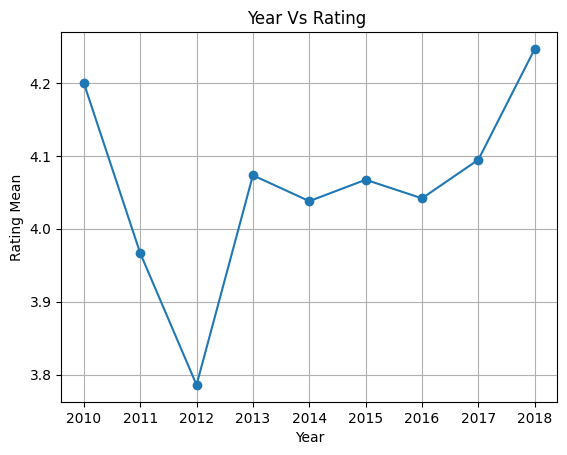

In [16]:
plt.plot(year_avg_rating,marker='o')
plt.xticks(year_avg_rating.index)
plt.xlabel("Year")
plt.ylabel("Rating Mean")
plt.title("Year Vs Rating ")
plt.grid()

In [22]:
rating_trend = store.groupby('year')['Rating'].mean()

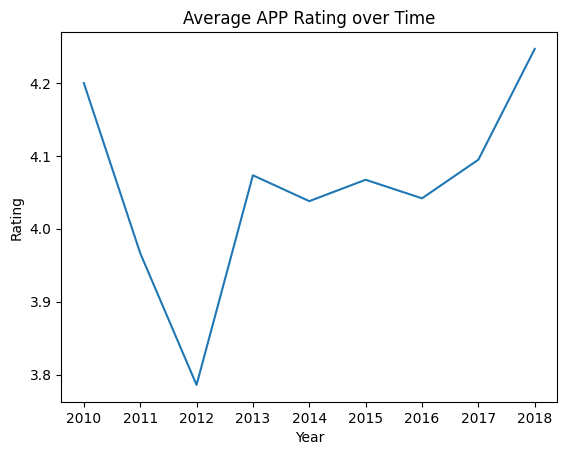

In [24]:
rating_trend.plot(kind='line')
plt.title("Average APP Rating over Time")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

In [ ]:
#2.How have total installs grown over the years?


In [33]:
store['Installs']=store['Installs'].str.replace('+','').str.replace(',','')
store['Installs']=pd.to_numeric(store['Installs'],errors='coerce')



<Axes: xlabel='year'>

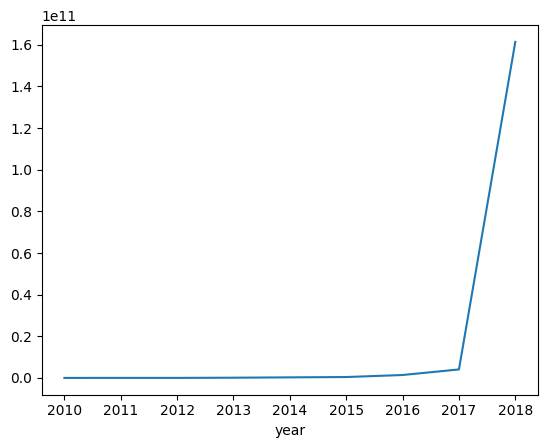

In [35]:
installs_trend = store.groupby('year')['Installs'].sum()
installs_trend.plot()
